In [1]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx

import sys
import matplotlib.pyplot as plt
import scanpy as sc 
# import decoupler as dc 
# from scipy.stats import pearsonr
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm

from src.helper import *

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt, quantile_transformation, zscore_transformation
from task_grn_inference.src.process_data.perturbation.normalization.script import normalize_func


%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'

par = {
    'input_dir': 'input/',
    'age_groups': ['34-', '35_44', '45_54', '55_64', '65_75']
    }

genesets_dict = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets_dict.values())))

# Create a DataFrame for pathway annotations
pathway_assignments = []
for pathway, genes in genesets_dict.items():
    for gene in genes:
        pathway_assignments.append((gene, pathway))

pathway_df = pd.DataFrame(pathway_assignments, columns=['gene', 'pathway']).set_index('gene')


df = pd.read_csv('https://www.tau.ac.il/~elieis/HKG/HK_genes.txt', sep=' ', header=None)
housekeeping_genes = set(df.loc[:, 0])

In [2]:
adata_a = ad.read_h5ad('output/data/35_44.h5ad')
def calculate_corr(X):
    try:
        X = X.todense().A
    except:
        pass
    return np.corrcoef(X.T)

In [3]:
adata_a_d = adata_a[adata_a.obs.age_donor=='44_B01']
adata_a_d = basic_qc(adata_a_d, min_genes_per_cell=10, min_cells_per_gene=10)

sc.pp.normalize_total(adata_a_d)
sc.pp.log1p(adata_a_d)
# sc.pp.scale(adata_a_d)
# # sc.experimental.pp.normalize_pearson_residuals(adata_a_d)

try: 
    X = adata_a_d.X.todense().A.copy()
except:
    X = adata_a_d.X.copy()

shape before  (4071, 11341)
shape after  (4071, 11018)


In [4]:
# Get explained variance from the PCA results
if False:
    sc.pp.pca(adata_a_d, n_comps=50)
    explained_variance = adata_a_d.uns['pca']['variance_ratio']

    plot_cumulative_density(explained_variance)

5
10
100
500
2000


Text(0.5, 0, 'Corr. coeff')

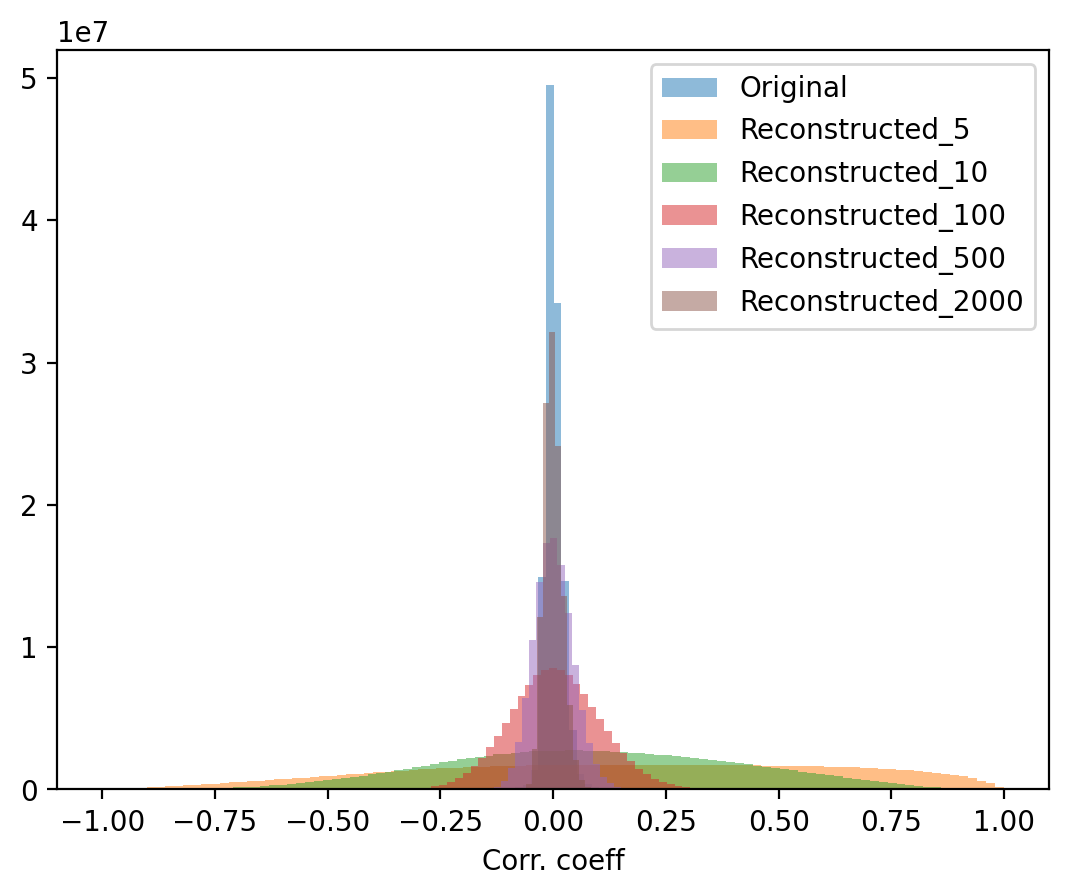

In [5]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import mean_squared_error

# def denoise(X, n_components):
#     pca = TruncatedSVD(n_components=n_components) #TODO: center
#     X_pca = pca.fit_transform(X)
#     X_reconstructed = pca.inverse_transform(X_pca)
#     reconstruction_error = mean_squared_error(X, X_reconstructed)
#     print(f"Reconstruction MSE: {reconstruction_error}")
#     return X_reconstructed


import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def corr_latent_space(X, n_components):
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_standardized = scaler.fit_transform(X)
    pca = PCA(n_components=n_components)
    Z = pca.fit_transform(X_standardized)  
    W_k = pca.components_.T 
    covariance_matrix = W_k @ W_k.T  
    std_dev = np.sqrt(np.diag(covariance_matrix))
    correlation_matrix = covariance_matrix / np.outer(std_dev, std_dev)
    return correlation_matrix

# - corr genes
corr_un = calculate_corr(X)
aa = plt.hist(corr_un.flatten(), bins=100, label='Original', alpha=0.5)
mask_zeros = (X==0)

for n_components in [5, 10, 100, 500, 2000]:
    print(n_components)
    # X_reconstructed = denoise(X, n_components)
    # X_reconstructed = np.where(mask_zeros, X_reconstructed, 0)
    # corr_un_den = calculate_corr(X_reconstructed)
    corr_un_den = corr_latent_space(X, n_components)
    aa = plt.hist(corr_un_den.flatten(), bins=100, label=f'Reconstructed_{n_components}', alpha=0.5)
plt.legend()
plt.xlabel('Corr. coeff')